<a href="https://colab.research.google.com/github/imranfaiz-an/NYC_Zoning-DS-30195/blob/main/mircro_project_zoning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Zoning & Land Use - An Overview from New York City

Muhammad Faizan Imran - DS-30195

This notebook sets up zoning as a policy lever, provides a brief qualitative history and explores some zoning changes that took place in NYC and what kind of impact they had on the immediate surroundings. 

Zoning amendments are quite frequent in NYC and I would like to develop this tool to quantify the impact of prior changes to allow for a more informed discussion around future proposal and their impact on the community.

## Backgroud

Zoning as an urban planning tool has been around for over a century in the US, outlining how a given physical space can be used. The need for government to intervene and regulate the use of parcels of land grew out of rapid population growth toward the end of the 19th century, coupled with technological innovation and a large influx of immigrants. Together, these forces produced overcrowded, poorly built tenements with no quality or safety assurances, eventually giving rise to the Tenement House Act of 1901 — a law passed in response to widespread concern over deteriorating living conditions across New York City.

This act marked a meaningful shift away from the laissez-faire attitudes that dominated the era. As Seymour Toll captures in his book Zoned American: "In evolution Spencer found the building blocks of social Darwinism. Evolution is an iron law of the universe. Laissez faire is its indispensable condition... the Englishman's thinking penetrated the social sciences of the era." This intellectual climate led thinkers like Richard Hofstadter, a professor of American History at Columbia, to call for a "holy war against reformism, protectionism, socialism, and government interventionism." Lochner v. New York (1905) illustrates this sentiment well: the Supreme Court ruled in favor of Lochner, who argued that New York State could not constitutionally cap his bakers at more than 10 hours of work per day, framing it as a violation of his 14th Amendment right to freely contract for labor.

The Tenement Act of 1901 was significant as an early step in the right direction during the Progressive Era, but it was not the only catalyst for zoning. The rapid proliferation of skyscrapers — massive structures that cast shadows over surrounding buildings and choked streets of light and air — created additional pressure for regulation. The roots of land use segregation, however, ran darker. The so-called "Laundry Cases" of 1885 in San Francisco reveal an early and troubling precedent: laundries were permitted across the city, except in Chinatown, effectively targeting a specific ethnic community under the guise of neutral regulation. This pattern continued through ostensibly race-neutral laws — such as limits on air per square foot in a dwelling — that were designed and applied to burden specific populations. These examples illustrate how zoning and land use law, from their earliest iterations, could be weaponized against racial minorities.

This background sets the stage to dive into the nuances of this policy and understand its broader present-day implications.

## Zoning in NYC (1916, 1961 - Present)

New York City took the lead in implementing zoning and land use as a policy by implementing the Zoning Resolution of 1916 — a document outlining permitted building uses and heights, and dividing the city into separate commercial, residential, and unrestricted districts. Its influence was immediate and far-reaching: it shaped the design of many buildings constructed during that era, including the iconic "wedding cake" style towers that set back progressively as they rose, and served as a model adopted by cities across the country.

Following Roosevelt's New Deal, government took on a far more active role in shaping cities and urban spaces. The Federal Highway Act of 1916 and, later, the Interstate Highway Act of 1956 together fueled a decisive shift toward car-dependent travel, restructuring how cities grew and where people lived. The role of the Home Owners' Loan Corporation (HOLC) and Federal Housing Authority (FHA) in shaping — and distorting — urban spaces through redlining has also been well documented. This expanding federal footprint in urban planning, combined with growing demand from New Yorkers for more green space and a more livable city, set the stage for the 1961 Zoning Resolution. This update introduced a much wider array of zoning concepts, formally dividing the city into three major districts — Residential, Commercial, and Manufacturing — each with detailed sub-categories like parking space allotment for building and much more that we will explore throughout this notebook. 

The 1961 Resolution also introduced incentive zoning tools, encouraging developers to incorporate publicly accessible open spaces into their projects in exchange for additional building density. Since then, the Resolution has undergone continued adjustments and amendments. New York City allows individuals and organizations to propose zoning amendments, which are then reviewed and voted on by the City Council before being accepted or rejected.

In [ ]:
!pip install -q census us geopandas polars pandas matplotlib pathlib plotly json nbformat folium sodapy shapely

zsh:1: command not found: pip


In [42]:
import geopandas as gpd
import polars as pl
import pandas as pd
import matplotlib.pyplot as plt
import folium
import pathlib
import plotly.express as px
import json
import nbformat
import folium
from sodapy import Socrata
from shapely.geometry import Point

## Exploring the NYC Open Data Zoning Amendments Shapefile

In [106]:
!curl -L -o nycgiszoningfeatures_202603shp.zip "https://raw.githubusercontent.com/imranfaiz-an/NYC_Zoning-DS-30195/main/data/nycgiszoningfeatures_202603shp.zip"
!unzip -o nycgiszoningfeatures_202603shp.zip -d nycgiszoningfeatures_202603shp

amendments_gdf = gpd.read_file("nycgiszoningfeatures_202603shp/nycgiszoningfeatures_202603shp/nyzma.shp")
amendments_gdf.crs

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 4991k  100 4991k    0     0  3746k      0  0:00:01  0:00:01 --:--:-- 3747k
Archive:  nycgiszoningfeatures_202603shp.zip
   creating: nycgiszoningfeatures_202603shp/nycgiszoningfeatures_202603shp
  inflating: nycgiszoningfeatures_202603shp/__MACOSX/._nycgiszoningfeatures_202603shp  
  inflating: nycgiszoningfeatures_202603shp/nycgiszoningfeatures_202603shp/nysp_sd.shp  
  inflating: nycgiszoningfeatures_202603shp/__MACOSX/nycgiszoningfeatures_202603shp/._nysp_sd.shp  
  inflating: nycgiszoningfeatures_202603shp/nycgiszoningfeatures_202603shp/nyzd.shx  
  inflating: nycgiszoningfeatures_202603shp/__MACOSX/nycgiszoningfeatures_202603shp/._nyzd.shx  
  inflating: nycgiszoningfeatures_202603shp/nycgiszoningfeatures_202603shp/nylh.sbx  
  inflating: nycgiszoningfeatures_202603shp/__MACOSX/nycgiszoningfeatures_202603shp/._nylh.sbx  


<Projected CRS: EPSG:2263>
Name: NAD83 / New York Long Island (ftUS)
Axis Info [cartesian]:
- X[east]: Easting (US survey foot)
- Y[north]: Northing (US survey foot)
Area of Use:
- name: United States (USA) - New York - counties of Bronx; Kings; Nassau; New York; Queens; Richmond; Suffolk.
- bounds: (-74.26, 40.47, -71.8, 41.3)
Coordinate Operation:
- name: SPCS83 New York Long Island zone (US survey foot)
- method: Lambert Conic Conformal (2SP)
Datum: North American Datum 1983
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

In [3]:
# @markdown Looking at what information we have in the amendments shapefile data

amendments_gdf.head(5)

,EFFECTIVE,STATUS,ULURPNO,LUCATS,PROJECT_NA,Shape_Leng,Shape_Area,geometry
0,NaT,Adopted,810449zmk,810449,STOCKTON AVE BET MARCY & TOMPKINS A,415.529950,1.324127e+04,"POLYGON ((998502.635 193115.2, 998502.746 1931..."
1,2005-07-27,Adopted,050400zmq,050400,CAMBRIA HEIGHTS,32248.221450,3.439392e+07,"POLYGON ((1054990.46 191898.552, 1054655.357 1..."
2,2001-07-26,Adopted,010199zmy,010199,UNIFIED BULK PROGRAM,23168.592620,1.353171e+07,"MULTIPOLYGON (((986463.758 192992.53, 986599.4..."
3,1987-08-19,Adopted,870651zmx,870651,POWERS AVE FAMILY RESIDENCE CENTER,1516.964698,1.290082e+05,"POLYGON ((1008627.059 233293.063, 1008805.258 ..."
4,1983-10-06,Adopted,830876zmx,830876,STORY OLMSTEAD HOMER & PUGSLEY AVES,5416.972164,1.716759e+06,"POLYGON ((1024105.242 239793.096, 1024771.443 ..."


### Amendment Types

The zoning amendments in our data have either been adopted or are certified, meaning that the application has been filed and is in public review by the City.

In [4]:
amendments_gdf.value_counts(["STATUS"]) # 26 applications are currently undergoing public review

STATUS   
Adopted      1381
Certified      26
Name: count, dtype: int64

In [3]:
# @markdown Another intersting thing to look at would be how often zoning amendments are made by years.
# @markdown Note that this would only give counts for amendments that have been adopted since those certified do not yet have a value for the EFFECTIVE column

amendments_gdf["effective_year"] = amendments_gdf["EFFECTIVE"].dt.year.astype("Int64")
amendments_gdf.value_counts("effective_year").head(5)

effective_year
2021    60
2005    50
2025    48
2009    45
2008    42
Name: count, dtype: int64

In [6]:
# We can also work with the original column given to get the counts by year ends
amendments_gdf.groupby([pd.Grouper(key="EFFECTIVE", freq="YE")])["STATUS"].count().sort_values(ascending=False).head(7)

EFFECTIVE
2021-12-31    60
2005-12-31    50
2025-12-31    48
2009-12-31    45
2019-12-31    42
2008-12-31    42
2022-12-31    41
Name: STATUS, dtype: int64

In [7]:
amendments_gdf.sort_values(by="EFFECTIVE", ascending=False)

,EFFECTIVE,STATUS,ULURPNO,LUCATS,PROJECT_NA,Shape_Leng,Shape_Area,geometry,effective_year
1406,2026-03-26,Adopted,240271zmk,240271,20 Berry Street,979.834834,59808.791315,"POLYGON ((996421.642 202451.274, 996600.693 20...",2026
1401,2026-03-10,Adopted,260038zmk,260038,395 Flatbush Avenue Ext. Redevelopment,1365.505679,93861.735660,"POLYGON ((989539.117 190262.76, 989387.916 190...",2026
1400,2026-03-10,Adopted,240334zmq,240334,33-01 11th Street Rezoning,1083.824518,72840.164059,"POLYGON ((1001876.697 218690.438, 1002115.147 ...",2026
1399,2026-03-10,Adopted,240079zmq,240079,14-10 Beach Channel Drive Rezoning,843.767374,40579.869857,"POLYGON ((1052519.297 160921.792, 1052566.54 1...",2026
1376,2026-02-24,Adopted,250332zmk,250332,1417 Ave U Rezoning,891.691642,48244.624036,"POLYGON ((996098.86 157413.105, 996072.291 157...",2026
...,...,...,...,...,...,...,...,...,...
1385,NaT,Certified,260048zmk,260048,9201 4th Ave Rezoning,818.757686,36652.159471,"POLYGON ((975830.933 164421.294, 975873.469 16...",<NA>
1402,NaT,Certified,260135zmk,260135,132 Melrose Street Rezoning,486.861567,14774.310978,"POLYGON ((1002991.871 194090.864, 1002892.581 ...",<NA>
1403,NaT,Certified,240218zmk,240218,Park Avenue Brooklyn Rezoning,2531.542321,274218.134791,"POLYGON ((996590.349 192921.866, 996551.512 19...",<NA>
1404,NaT,Certified,250331zmq,250331,189-10 Northern Boulevard Rezoning,1750.877295,115861.923176,"POLYGON ((1041889.24 215248.759, 1041871.127 2...",<NA>


(1976.0, 2027.0)

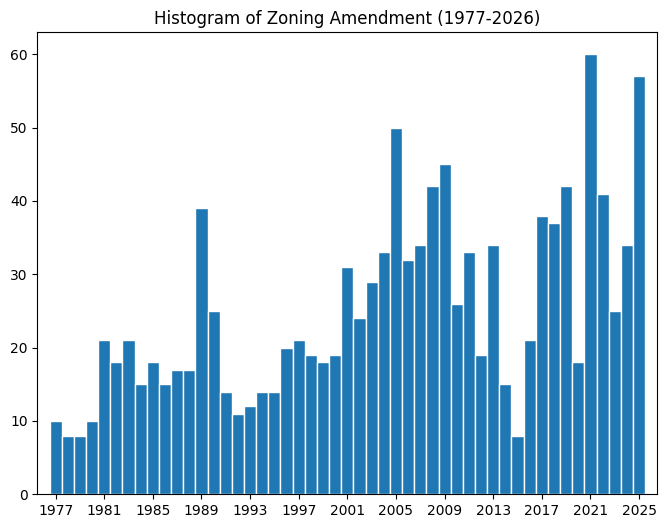

In [8]:
# Plotting number of amendments by year
import numpy as np
years = amendments_gdf["EFFECTIVE"].dropna().dt.year.astype(int)

fig, ax = plt.subplots(figsize=(8,6))
bins = np.arange(1977, 2027, 1)
ax.hist(years, bins=bins, edgecolor="white")

tick_years = np.arange(1977, 2027, 4)
ax.set_xticks(tick_years + 0.5)
ax.set_xticklabels(tick_years)
ax.set_title("Histogram of Zoning Amendment (1977-2026)")
ax.set_xlim(1976, 2027)

We see a massive uptick in zoning amendments adopted in 2021, during covid, this was also the year former Mayor Bill de Blasio's term ended and in 2025 Mayor Eric Adams closing year as the mayor. A gradual increase to amendments in the years leading up to the financial crisis is also notable.

In [4]:
# Loading in data for NYC borough level shapefiles

borough_nyc = gpd.read_file("https://data.cityofnewyork.us/resource/gthc-hcne.geojson")
print(borough_nyc.crs) 

EPSG:4326


(np.float64(905012.5881632194),
 np.float64(1075114.4093875955),
 np.float64(110655.14400095886),
 np.float64(280567.586671918))

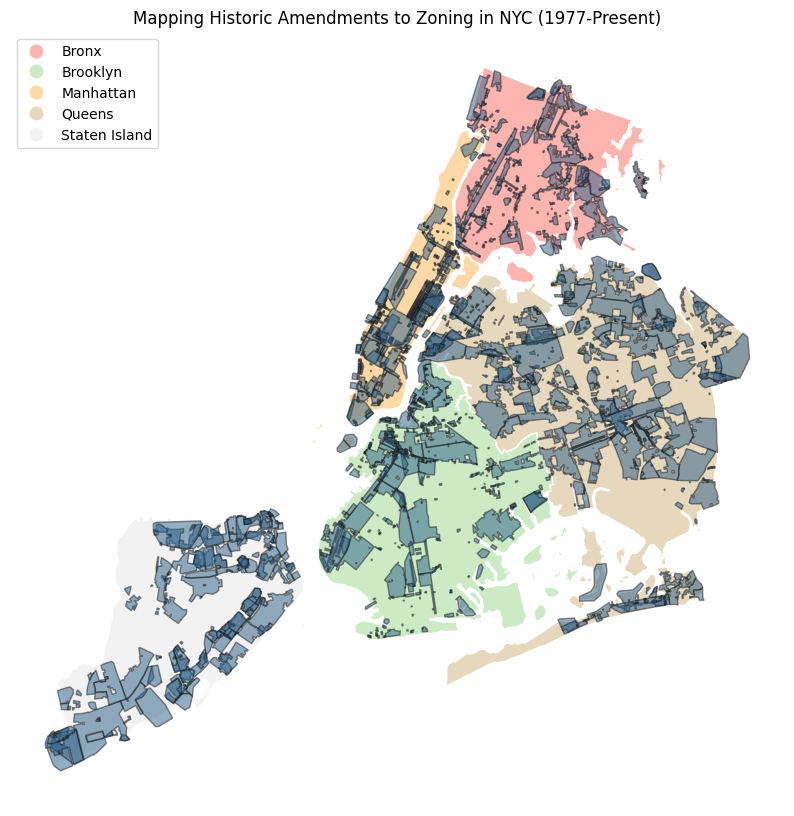

In [ ]:
# Plotting amendments on to the boroughs - Note that since CRS for the boroughs
# data is different we do harmonize it before mapping
fig, ax = plt.subplots(figsize=(10,15))
borough_nyc.to_crs(amendments_gdf.crs).plot(
    ax=ax, column="boroname", edgecolor="white", legend=True, cmap="Pastel1", legend_kwds={"loc": "upper left"}
)
amendments_gdf.plot(ax=ax, color="#2a5e86", edgecolor="0.1", alpha=0.5)
ax.set_title("Mapping Historic Amendments to Zoning in NYC (1977-Present)")
plt.axis("off")

From the above we can see that Manhattan, Queens and Staten Island have had large areas rezoned over the years and Brooklyn has had many small changes. We can also see that there have been on multiple zoning amendments over the same parcel of land for instance Upper East Side in Manhattan seems to have had multiple rezonings.

In [5]:
# We can do a spatial join to quantify exactly how many amendments have been made 
# by each borough

amendments_gdf = amendments_gdf[amendments_gdf.geometry.notna()]
borough_nyc = borough_nyc[borough_nyc.geometry.notna()]

borough_projected = borough_nyc.to_crs(amendments_gdf.crs) # storing the projected borough data

amendments_borough_gdf = amendments_gdf.sjoin(borough_projected)

In [12]:
amendments_borough_gdf.value_counts("boroname") # This adds up to 1416 but we started with 1407 total amendments suggesting there were a few edge cases that intersected with two or more boroughs

boroname
Brooklyn         414
Queens           374
Manhattan        274
Bronx            206
Staten Island    148
Name: count, dtype: int64

## Zoning Land Use Change

One limitation of the zoning data we are using in this notebook is that the data does not say what the change is - i.e., whether a residential land use is being changed to commercial or manufacturing or some other use case. It could also be from residential to a different residential with a larger area. 

However the city does publish a file with current outlining the current zoning status of all land parcels in the city. We will be exploring that geospatial data below.

In [ ]:
# Loadint the zoning districts shapefile and looking at the top 10 most frequent districts
zoning_districts_gdf = gpd.read_file("nycgiszoningfeatures_202603shp/nycgiszoningfeatures_202603shp/nyzd.shp")
zoning_districts_gdf[zoning_districts_gdf['ZONEDIST'] != "PARK"].value_counts("ZONEDIST").head(10)

ZONEDIST
R6A     189
R6B     186
M1-1    184
R3-2    166
R5      165
R4-1    163
R4      162
R6      147
R7A     146
R5B     138
Name: count, dtype: int64

In [ ]:
# We can further create a variable to group residential, commercial and manufacturing districts together
district_map = {
    "R": "Residential",
    "C": "Commercial",
    "M": "Manufacturing",
    "P": "Parks",
}

zoning_districts_gdf["simplified_district"] = (
    zoning_districts_gdf["ZONEDIST"]
    .str[0]
    .map(district_map)
)

zoning_districts_gdf.value_counts("simplified_district")

simplified_district
Residential      2736
Parks            1253
Commercial        751
Manufacturing     670
Name: count, dtype: int64

(np.float64(905296.9580748982),
 np.float64(1075056.4935879551),
 np.float64(110564.20267499685),
 np.float64(280673.08384763))

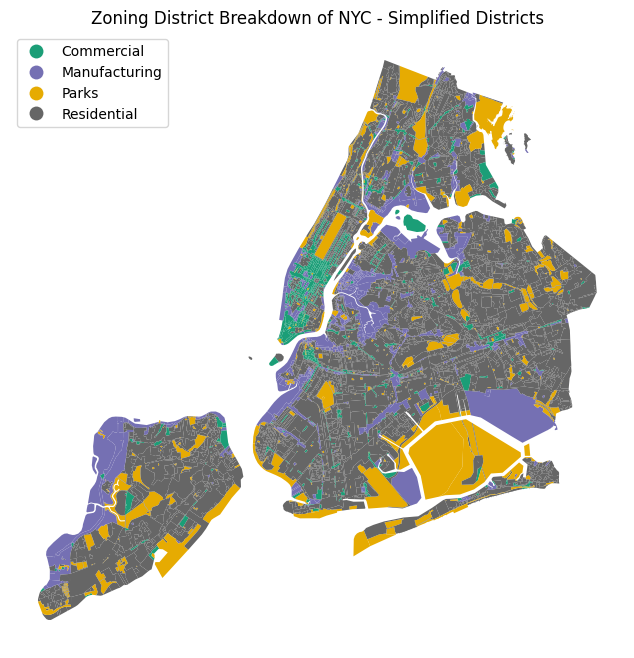

In [ ]:
# Mapping the main zoning categories
fig, ax = plt.subplots(figsize=(8,8))

zoning_districts_gdf.plot(ax=ax, column="simplified_district", legend=True, cmap="Dark2", legend_kwds={"loc": "upper left"})
ax.set_title("Zoning District Breakdown of NYC - Simplified Districts")
ax.axis("off")

In [ ]:
# To get a better sense of the districts and how they are distributed we can make a plotly map

zoning_districts_plotly = zoning_districts_gdf.to_crs(epsg=4326) # to make a plotly map we need to change our projection 

fig = px.choropleth_map(zoning_districts_plotly,
                           geojson=zoning_districts_plotly.geometry,
                           locations=zoning_districts_plotly.index,
                           color="simplified_district",
                           color_discrete_sequence=px.colors.qualitative.Bold,
                           center={"lat": 40.7128, "lon": -74.0060},
                           map_style="open-street-map",
                           zoom=9.5,
                           opacity=0.7,
                           title="Zoning District Breakdown of NYC",
                           hover_data=['ZONEDIST'])

fig.update_layout(margin={"r": 0, "t": 30, "l": 0, "b": 0})
fig.show()

Playing around with the above map and zooming in we see how each category is split up into further subcategories. For example residential districts are further subdivided into districts from R1 which are detached sigle family homes to R10 which deonte residential skyscrappers and everything in between. Similarly commercial districts go from C1-C8 and manufacturing disctricts from M1-M3. As the numbers go up so does the scale of the use. 

There are other elements that are used by the City to add further use cases to the different districts like encoding parking requirements and the scale of the development. For this project we will be focusing on the broader district definitions.

# Zoning Change and 311 Data

To understand the impact of a large scale zoning change we can attempt to link it with the 311 complaint date to do a simple befre and after complaint comparison in and around the rezoned area. Linking zoning with complaints data can allow us to get some understanding of how the change was received by the population and we can also look at the types of complaints changed before and after the amendment.

For this project we will be looking at the rezoning project undertaken by the Department of City Planning for South Jamaica in Queens. The zonings main stated goal was to preserve the lower density characteristic of the neighborhood and at same time allowing for a more targetted increase in commercial districts. It is the second largest rezoning by total area in New York City.

Below we take a closer look at the area rezoned. 

In [ ]:
# Let's visualize the scope of the amendment using a folium map
queens = borough_projected[borough_projected['boroname'] == "Queens"].to_crs("EPSG:4326")
south_jamaica = amendments_gdf[amendments_gdf['PROJECT_NA'] == "SOUTH JAMAICA"].to_crs("EPSG:4326")
south_jamaica['EFFECTIVE'] = south_jamaica['EFFECTIVE'].astype(str)

# Center map on Queens
bounds = queens.total_bounds  # [minx, miny, maxx, maxy]
center = [(bounds[1] + bounds[3]) / 2, (bounds[0] + bounds[2]) / 2]

m = folium.Map(location=center, zoom_start=12, tiles="CartoDB positron")

# Adding Queens Layer
folium.GeoJson(
    queens,
    name="Queens Neighborhoods",
    style_function=lambda x: {
        "fillColor": "#b45c5c",
        "color": "#0A0909",
        "weight": 1.5,
        "fillOpacity": 0.6,
    },
    tooltip=folium.GeoJsonTooltip(
        fields=["boroname"],       
        aliases=["Borough"]
    )
).add_to(m)

# Adding Amendment Layer
folium.GeoJson(
    south_jamaica,
    name="South Jamaica Rezoning",
    style_function=lambda x: {
        "fillColor": "#0091FF",
        "color": "#111111",
        "weight": 1,
        "fillOpacity": 0.5,
    },
    tooltip=folium.GeoJsonTooltip(
        fields=["PROJECT_NA", "EFFECTIVE"],
        aliases=["Project", "Date of Adoption"]
    )
).add_to(m)

title_html = """
<div style="position: fixed; top: 15px; left: 50%; transform: translateX(-50%);
            z-index: 1000; background: white; padding: 8px 16px;
            border-radius: 6px; box-shadow: 0 2px 6px rgba(0,0,0,0.2);
            font-family: sans-serif; font-size: 14px; font-weight: bold;">
    Mapping The Extent of the 2011 Jamaica Rezoning in Queens
</div>
"""
m.get_root().html.add_child(folium.Element(title_html))

folium.LayerControl().add_to(m)

# Fit map to Queens bounds
m.fit_bounds([[bounds[1], bounds[0]], [bounds[3], bounds[2]]])

m

## Getting 311 Data & Creating a Buffer Around Amendment Zone

To analyze the impact of the change we can create a buffer of 1/2 miles around the area adopting the change to track how things change.

In [36]:
borough_projected

,borocode,boroname,shape_area,shape_leng,geometry
0,5,Staten Island,1623618358.46,325912.288988,"MULTIPOLYGON (((970217.022 145643.332, 970227...."
1,3,Brooklyn,1934462607.75,726953.04509,"MULTIPOLYGON (((1022227.32 152028.146, 1022078..."
2,4,Queens,3041419716.32,887902.903727,"MULTIPOLYGON (((1032452.015 154469.237, 103245..."
3,1,Manhattan,636631537.285,359537.906171,"MULTIPOLYGON (((981219.056 188655.316, 980940...."
4,2,Bronx,1187199168.58,463146.326689,"MULTIPOLYGON (((1012821.806 229228.265, 101278..."


(np.float64(990969.9514007879),
 np.float64(1071021.201614378),
 np.float64(131963.27253114074),
 np.float64(235881.55467834196))

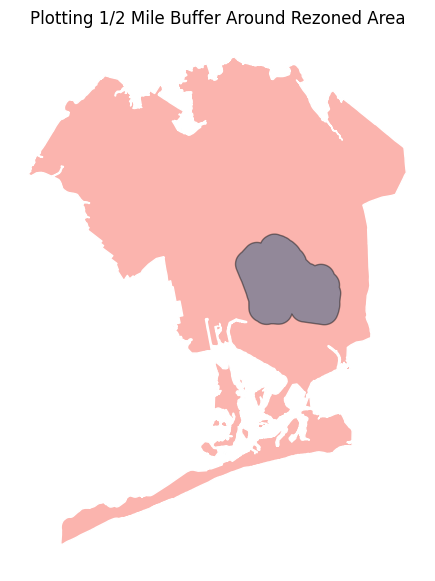

In [43]:
jamaica_amendment = amendments_gdf[amendments_gdf['PROJECT_NA'] == "SOUTH JAMAICA"] # Adopted in May of 2011
jamaica_amendment['geometry'] = jamaica_amendment.buffer(2640)

fig, ax = plt.subplots(figsize=(7,7))
borough_projected[borough_projected['boroname'] == "Queens"].plot(
    ax=ax, edgecolor="white", cmap="Pastel1"
)

jamaica_amendment.plot(ax=ax, color="#2a5e86", edgecolor="0.1", alpha=0.5)
ax.set_title("Plotting 1/2 Mile Buffer Around Rezoned Area")
plt.axis("off")

In [ ]:
# Let's get the 311 data to do some analysis - Note that this takes around 3 mintues to run
client = Socrata("data.cityofnewyork.us", 
                app_token="5r92XJz6OaT3JygWksrIhsYGw",  
                timeout=60)

results = client.get("76ig-c548",   # 311 dataset for 2010-2020
                    limit=2001000,
                    where="created_date > '2011-01-01' AND created_date < '2011-12-31' AND borough == 'QUEENS'")


df_311_2011 = pd.DataFrame.from_records(results)

In [ ]:
# We need to make sure the lats and longs are there in the data before the spatial join
df_311_clean = df_311_2011.dropna(subset=['longitude', 'latitude'])
df_311_clean = df_311_clean[
    (df_311_clean['longitude'] != 0) & 
    (df_311_clean['latitude'] != 0)
]

df_311_2011_gdf = gpd.GeoDataFrame(
    df_311_clean,
    geometry=gpd.points_from_xy(df_311_clean['longitude'], df_311_clean['latitude']),
    crs='EPSG:4326'
).to_crs(epsg=2263) # Converting to NYC crs

True


In [ ]:
complaints_jamaica = gpd.sjoin(df_311_2011_gdf, jamaica_amendment, how='inner', predicate='within')
len(complaints_jamaica) # We get 37000 complaints for Jamaica rezoning area including the buffer

In [ ]:
# Looking at the complaint breakdown
complaints_jamaica.value_counts("complaint_type")

complaint_type
Sewer                          2968
Street Condition               2330
Street Light Condition         2048
Noise - Residential            1896
Dirty Conditions               1866
                               ... 
Found Property                    1
Plant                             1
Bottled Water                     1
Highway Sign - Damaged            1
Animal Facility - No Permit       1
Name: count, Length: 134, dtype: int64

In [80]:
# Convert to datetime
complaints_jamaica['created_date'] = pd.to_datetime(complaints_jamaica['created_date'])
complaints_jamaica['closed_date'] = pd.to_datetime(complaints_jamaica['closed_date'])

# Split by cutoff date
cutoff = pd.Timestamp('2011-05-11') 

complaints_jamaica_before = complaints_jamaica[complaints_jamaica['created_date'] < cutoff]
complaints_jamaica_after  = complaints_jamaica[complaints_jamaica['created_date'] >= cutoff]

print(f"Complaints before: {len(complaints_jamaica_before):,}")
print(f"Complaints after:  {len(complaints_jamaica_after):,}")

Complaints before: 11,828
Complaints after:  25,773


In [ ]:
# Getting complaint counts into a separate df for percent analysis
before_counts = complaints_jamaica_before['complaint_type'].value_counts()
after_counts  = complaints_jamaica_after['complaint_type'].value_counts()

comparison = pd.DataFrame({
    'before': before_counts,
    'after':  after_counts
}).fillna(0)  # fills 0 for types that didn't exist in one period

comparison.index = comparison.index.str.strip().str.replace(r's$', '', regex=True)
comparison = comparison.groupby(level=0).sum()

comparison = comparison[(comparison['before'] > 50) & (comparison['after'] > 50)] # adding a cutoff at 50 to ignore infrequent complaints
comparison['pct_change'] = ((comparison['after'] - comparison['before']) / comparison['before'] * 100).round(2)

comparison.sort_values('pct_change', ascending=False).head(5) 

,before,after,pct_change
complaint_type,,,
Damaged Tree,119.0,1109.0,831.93
Overgrown Tree/Branche,86.0,566.0,558.14
NONCONST,166.0,709.0,327.11
PLUMBING,296.0,1189.0,301.69
Noise - Residential,378.0,1518.0,301.59


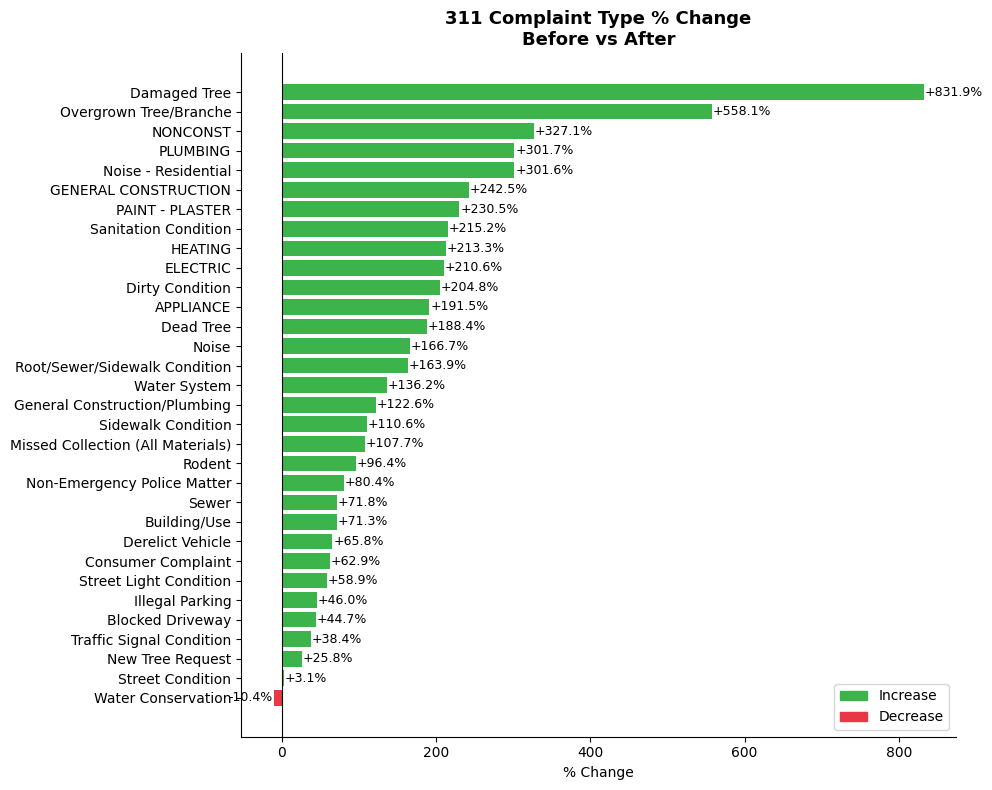

In [ ]:
import matplotlib.patches as mpatches

df_plot = comparison.sort_values('pct_change')
colors = ['#E83845' if x < 0 else '#3CB44B' for x in df_plot['pct_change']]
fig, ax = plt.subplots(figsize=(10, 8))

bars = ax.barh(df_plot.index, df_plot['pct_change'], color=colors, edgecolor='none')

for bar, val in zip(bars, df_plot['pct_change']):
    ax.text(
        val + (1 if val >= 0 else -1),
        bar.get_y() + bar.get_height() / 2,
        f'{val:+.1f}%',
        va='center',
        ha='left' if val >= 0 else 'right',
        fontsize=9
    )

# Reference line at 0
ax.axvline(0, color='black', linewidth=0.8)

# Legend
ax.legend(handles=[
    mpatches.Patch(color='#3CB44B', label='Increase'),
    mpatches.Patch(color='#E83845', label='Decrease')
])

ax.set_xlabel('% Change')
ax.set_title('311 Complaint Type % Change\nBefore vs After', fontsize=13, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

We see a dramatic increase in complaints across almost all dimensions post the zoning amendment being implemented, even though we are comparing 5 months with 7 months the percent different cannot be explained solely by the time difference.

## Checking Complaints for 2010 & 2012

To do a further sanity check we can bring in 311 data for 2010 and 2012 to see if there was something else happening in the second half of 2011 that could also explain the increase in complaints.

In [74]:
# Checks to see the total complaints in 2010 and 2012
results_before = client.get("76ig-c548",
                    limit=2001000,
                    where="created_date < '2011-01-01' AND borough == 'QUEENS'")


df_311_pre = pd.DataFrame.from_records(results_before)

results_after = client.get("76ig-c548",
                    limit=2001000,
                    where="created_date >= '2012-01-01'  AND created_date < '2012-12-31' AND borough == 'QUEENS'")


df_311_post = pd.DataFrame.from_records(results_after)

In [77]:
# We need to make sure the lats and longs are there in the data before the spatial join
df_311_clean_pre = df_311_pre.dropna(subset=['longitude', 'latitude'])
df_311_clean_pre = df_311_clean_pre[
    (df_311_clean_pre['longitude'] != 0) & 
    (df_311_clean_pre['latitude'] != 0)
]

df_311_2010_gdf = gpd.GeoDataFrame(
    df_311_clean_pre,
    geometry=gpd.points_from_xy(df_311_clean_pre['longitude'], df_311_clean_pre['latitude']),
    crs='EPSG:4326'
).to_crs(epsg=2263)

complaints_jamaica_2010 = gpd.sjoin(df_311_2010_gdf, jamaica_amendment, how='inner', predicate='within')
len(complaints_jamaica_2010)

31374

In [79]:
# We need to make sure the lats and longs are there in the data before the spatial join
df_311_clean_post = df_311_post.dropna(subset=['longitude', 'latitude'])
df_311_clean_post = df_311_clean_post[
    (df_311_clean_post['longitude'] != 0) & 
    (df_311_clean_post['latitude'] != 0)
]

df_311_2012_gdf = gpd.GeoDataFrame(
    df_311_clean_post,
    geometry=gpd.points_from_xy(df_311_clean_post['longitude'], df_311_clean_post['latitude']),
    crs='EPSG:4326'
).to_crs(epsg=2263)

complaints_jamaica_2012 = gpd.sjoin(df_311_2012_gdf, jamaica_amendment, how='inner', predicate='within')
len(complaints_jamaica_2012)

35312

2010 had 31,374 complaints and 2012 had 35312 total complaints. Which shows that the increase in complaints was more persistant. This can mean that at least in the short-run the amendment did not have a positive impact on the people living in South Jamaica.

# References

[1] Seymour Toll (1969). Zoned America 

[2] Berry, C. (2001). Land Use Regulation and Residential Segregation: Does Zoning Matter? American Law and Economics Review, (2), 251–274. http://www.jstor.org/stable/42705390

[3] Department of City Planning NYC (2018). Zoning Handbook. https://www.nyc.gov/assets/planning/downloads/pdf/zoning/downloadable-zoning-resources/zoning-handbook-2018.pdf

[4] Department of City Planning NYC (2011). South Jamaica Rezoning. https://www.nyc.gov/assets/planning/downloads/pdf/zoning/downloadable-zoning-resources/zoning-handbook-2018.pdf

[5] New York City 1916 Zoning Resolution